<a href="https://colab.research.google.com/github/BhupenderNayak/pytorch_projects/blob/exercise_learnpytorch.io_task/learnpytorch_io_module_1execrise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import matplotlib.pyplot as plt
from torch import nn
from sklearn.model_selection import train_test_split
from pathlib import Path

weight = 0.3
bias  = 0.7

X = torch.arange( 0 , 1 , 0.01).unsqueeze(dim=1)
y = weight * X + bias
print(f"Number of Samples : {len(X)}")
print(f"Numver of Samples : {len(y)}")
print(f"First 10 Samples of x are : {X[:10]}")
print(f"First 10 Samples of y are : {y[:10]}")


Number of Samples : 100
Numver of Samples : 100
First 10 Samples of x are : tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])
First 10 Samples of y are : tensor([[0.7000],
        [0.7030],
        [0.7060],
        [0.7090],
        [0.7120],
        [0.7150],
        [0.7180],
        [0.7210],
        [0.7240],
        [0.7270]])


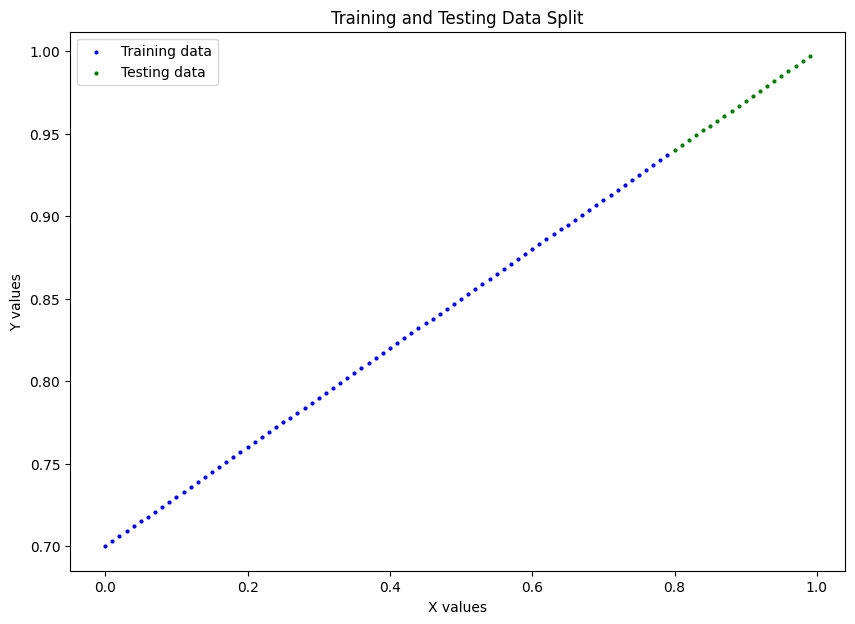

In [ ]:
X_train , X_test , y_train , y_test = train_test_split( X ,
                                                       y ,
                                                        test_size= 0.2 ,
                                                        shuffle = False ,
                                                        random_state = 42
                                                       )

plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c='b', s=4, label='Training data')
plt.scatter(X_test, y_test, c='g', s=4, label='Testing data')
plt.legend()
plt.title('Training and Testing Data Split')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.show()

In [ ]:
class ShivRajan(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1 , out_features=1 )

    def forward(self, x):
      return self.linear_layer(x)


torch.manual_seed(42)
model_1 = ShivRajan()
model_1.state_dict() , model_1
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD( model_1.parameters() , lr=0.01)
epoches = 300

for epoch in range(epoches):
    model_1.train()
    y_pred = model_1(X_train)
    loss = loss_fn(y_pred , y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch %20 ==0:
      model_1.eval()
      with torch.inference_mode():
        y_pred = model_1(X_test)
        test_loss = loss_fn( y_pred , y_test)
        print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")


Epoch: 0 | Train loss: 0.314 | Test loss: 0.532
Epoch: 20 | Train loss: 0.107 | Test loss: 0.279
Epoch: 40 | Train loss: 0.066 | Test loss: 0.171
Epoch: 60 | Train loss: 0.057 | Test loss: 0.137
Epoch: 80 | Train loss: 0.051 | Test loss: 0.119
Epoch: 100 | Train loss: 0.044 | Test loss: 0.102
Epoch: 120 | Train loss: 0.037 | Test loss: 0.086
Epoch: 140 | Train loss: 0.030 | Test loss: 0.070
Epoch: 160 | Train loss: 0.023 | Test loss: 0.054
Epoch: 180 | Train loss: 0.016 | Test loss: 0.038
Epoch: 200 | Train loss: 0.009 | Test loss: 0.021
Epoch: 220 | Train loss: 0.003 | Test loss: 0.005
Epoch: 240 | Train loss: 0.005 | Test loss: 0.004
Epoch: 260 | Train loss: 0.005 | Test loss: 0.004
Epoch: 280 | Train loss: 0.005 | Test loss: 0.004


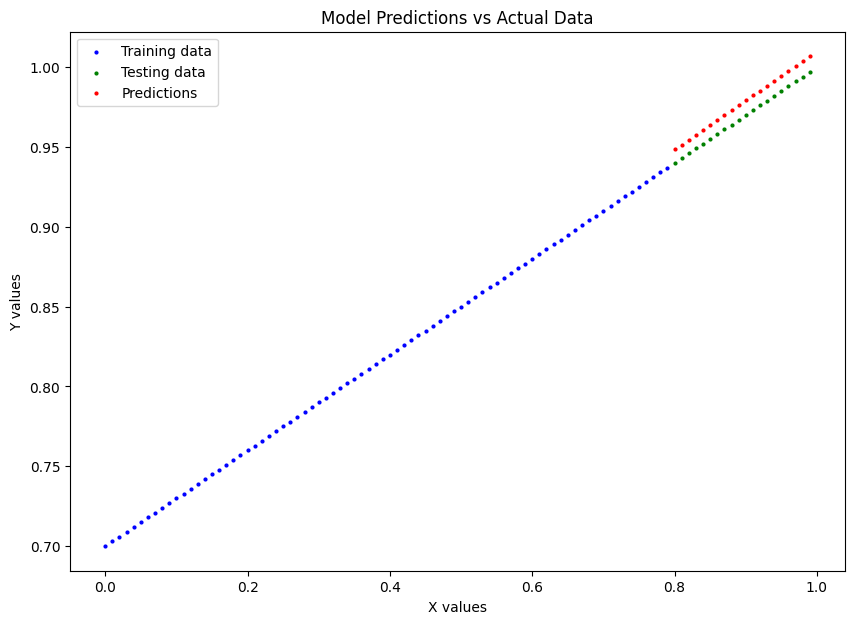

In [ ]:
model_1.eval()
with torch.inference_mode():
  y_pred = model_1(X_test)


plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c='b', s=4, label='Training data')
plt.scatter(X_test, y_test, c='g', s=4, label='Testing data')
plt.scatter(X_test, y_pred.cpu(), c='r', s=4, label='Predictions')
plt.legend()
plt.title('Model Predictions vs Actual Data')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.show()

In [ ]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True , exist_ok= True)

MODEL_NAME = "ShivRajanV1.model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(),f = MODEL_SAVE_PATH)

Saving model to models/ShivRajanV1.model


In [ ]:
loaded_model = ShivRajan()
loaded_model.load_state_dict(torch.load(f = MODEL_SAVE_PATH))
y_pred_new = loaded_model(X_test)
y_pred == y_preds_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [ ]:
loaded_model.state_dict()


OrderedDict([('linear_layer.weight', tensor([[0.3073]])),
             ('linear_layer.bias', tensor([0.7025]))])